# Seville Results Summary: Heat Escalation, Drought, and Fire Risk

Presentation-ready summary of Seville's four key climate-risk indicators, historical (ERA5, 1990-2025)
vs. projected (CMIP6 SSP5-8.5, `cmcc_esm2`, 2026-2045) -- raw model output and bias-corrected output
shown side by side, since the gap between them is often as important as the projection itself.

**Source data**: pulled directly from the already-validated comparison series built in
`seville_cmip6_projection_eda.ipynb` (Section 16) and `FWI_projections_last_2.ipynb` (Section 4.1) --
nothing is recomputed here, this notebook only reads and presents.

**One caveat that applies to every plot below, stated once rather than four times**: single model
(`cmcc_esm2`), single scenario (SSP5-8.5), no ensemble spread. Read every number as *directional risk
under one plausible pathway*, not a calibrated forecast -- and prefer the bias-corrected series over
the raw one, since the raw model carries known, documented biases in both temperature and
precipitation (detailed under each plot below).


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

OUT = "../Projected_SSP5-8.5/eda_outputs/seville"
OUT_LARISSA = "../Projected_SSP5-8.5/eda_outputs/larissa"

COLOR_HIST = "#6b6b6b"
COLOR_RAW = "#c1121f"
COLOR_CORRECTED = "#1b998b"
COLOR_REGRESSION = "tab:blue"
COLOR_NAIVE = "tab:purple"

def load(name, out_dir=OUT):
    return pd.read_csv(f"{out_dir}/{name}.csv", index_col="year")

def fit_baselines(df, window=None):
    """Best-fit linear regression (on the given historical window, None = full history)
    and the flat naive_full_mean baseline, both extrapolated across the projection years."""
    hist = df["era5_historical"].dropna()
    proj_index = df["cmip6_biascorrected"].dropna().index

    yrs, y = hist.index.values.astype(float), hist.values.astype(float)
    yrs_fit, y_fit = (yrs[-window:], y[-window:]) if window else (yrs, y)
    lr = stats.linregress(yrs_fit, y_fit)

    proj_yrs = proj_index.values.astype(float)
    regression_line = pd.Series(lr.intercept + lr.slope * proj_yrs, index=proj_index)
    naive_line = pd.Series(hist.mean(), index=proj_index)

    lr_corrected = stats.linregress(proj_yrs, df.loc[proj_index, "cmip6_biascorrected"].values.astype(float))

    return {
        "regression_line": regression_line, "naive_line": naive_line,
        "hist_slope_decade": lr.slope * 10, "hist_p": lr.pvalue,
        "hist_fit_years": (int(yrs_fit.min()), int(yrs_fit.max())),
        "corrected_slope_decade": lr_corrected.slope * 10, "corrected_p": lr_corrected.pvalue,
        "naive_value": hist.mean(),
    }

def plot_indicator(df, ylabel, title, baselines, regression_label):
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(df.index, df["era5_historical"], color=COLOR_HIST, lw=1.8, label="Historical (ERA5, 1990-2025)")
    ax.plot(df.index, df["cmip6_raw"], color=COLOR_RAW, lw=1.8, label="Projected, raw (SSP5-8.5, 2026-2045)")
    ax.plot(df.index, df["cmip6_biascorrected"], color=COLOR_CORRECTED, lw=2.2,
            label="Projected, bias-corrected (SSP5-8.5, 2026-2045)")
    ax.plot(baselines["regression_line"].index, baselines["regression_line"].values,
            "--", color=COLOR_REGRESSION, lw=2,
            label=f"Baseline: {regression_label}, extrapolated")
    ax.plot(baselines["naive_line"].index, baselines["naive_line"].values,
            ":", color=COLOR_NAIVE, lw=2,
            label=f"Baseline: naive_full_mean ({baselines['naive_value']:.2f})")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=12, loc="left")
    ax.legend(frameon=False, fontsize=8)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

def change_stats(df):
    hist = df["era5_historical"].dropna()
    raw = df["cmip6_raw"].dropna()
    corr = df["cmip6_biascorrected"].dropna()
    return {
        "hist_mean": hist.mean(), "raw_mean": raw.mean(), "corrected_mean": corr.mean(),
        "delta_corrected": corr.mean() - hist.mean(),
        "pct_corrected": 100 * (corr.mean() - hist.mean()) / hist.mean(),
        "delta_raw": raw.mean() - hist.mean(),
        "pct_raw": 100 * (raw.mean() - hist.mean()) / hist.mean(),
    }

def trend_note(b):
    sig = lambda p: "significant" if p < 0.05 else "not significant"
    ratio = b["corrected_slope_decade"] / b["hist_slope_decade"] if b["hist_slope_decade"] else float("nan")
    return (f"Historical regression ({b['hist_fit_years'][0]}-{b['hist_fit_years'][1]}): "
            f"{b['hist_slope_decade']:+.3f}/decade (p={b['hist_p']:.2f}, {sig(b['hist_p'])}).  "
            f"Corrected projection's own trend (2026-2045): {b['corrected_slope_decade']:+.3f}/decade "
            f"(p={b['corrected_p']:.2f}, {sig(b['corrected_p'])}).  Ratio: {ratio:+.2f}x")


## 1. Heat Escalation -- Mean Daily Maximum Temperature (`tmax_mean`)

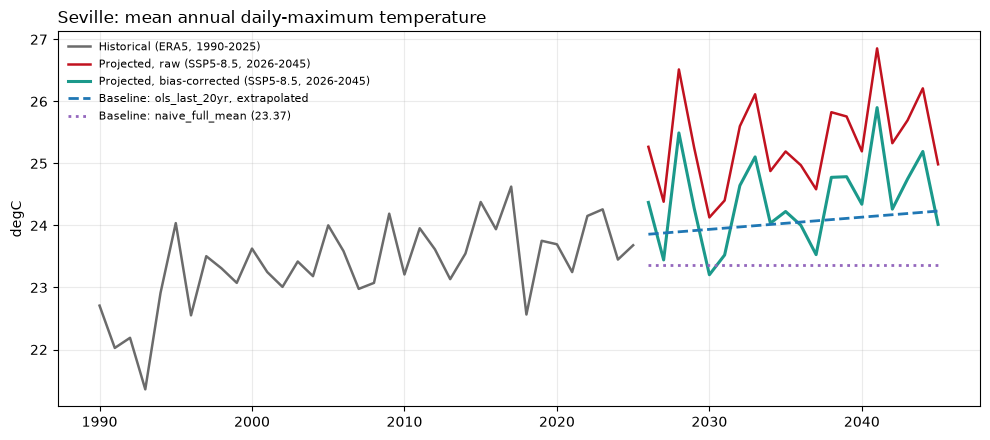

Historical mean: 23.37
Projected, bias-corrected: 24.39  (+1.03, +4.4%)
Projected, raw: 25.36  (+1.99, +8.5%)

Historical regression (2006-2025): +0.197/decade (p=0.35, not significant).  Corrected projection's own trend (2026-2045): +0.347/decade (p=0.21, not significant).  Ratio: +1.77x


In [2]:
tmax = load("seville_tmax_mean_era5_vs_cmip6_raw_vs_corrected")
s = change_stats(tmax)
b = fit_baselines(tmax, window=20)
plot_indicator(tmax, "degC", "Seville: mean annual daily-maximum temperature", b, "ols_last_20yr")
print(f"Historical mean: {s['hist_mean']:.2f}")
print(f"Projected, bias-corrected: {s['corrected_mean']:.2f}  ({s['delta_corrected']:+.2f}, {s['pct_corrected']:+.1f}%)")
print(f"Projected, raw: {s['raw_mean']:.2f}  ({s['delta_raw']:+.2f}, {s['pct_raw']:+.1f}%)")
print()
print(trend_note(b))


**Result: +1.03 degC (+4.4%), historical to bias-corrected projection.** Seville's daytime summer
heat continues escalating under SSP5-8.5 -- corrected mean daily maximum rises from 23.37 degC
(1990-2025) to 24.39 degC (2026-2045). The raw model shows a larger, less trustworthy jump (+1.99
degC, +8.5%) because the uncorrected model itself runs warmer than observed reality -- **use the
corrected number in the presentation, and note the raw number if asked why it looks larger.** This
is the first leg of the compound story: rising heat is the documented, statistically-established
starting point (p=0.0002 in the historical record alone) that the drought and fire legs below build
on.

**Trend comparison.** The historical regression (`ols_last_20yr`, fit 2006-2025) implies +0.20 degC/
decade; the bias-corrected projection's own trend over 2026-2045 runs steeper, +0.35 degC/decade --
about **1.8x faster**. Neither slope is individually statistically significant (p=0.35 and p=0.21), so
read this as "consistent with possible acceleration," not a confirmed one -- useful context if asked
"is warming speeding up," but not a number to put on a slide as settled fact.


## 2. Overall Warming -- Mean Daily Temperature (`t2m_mean`)

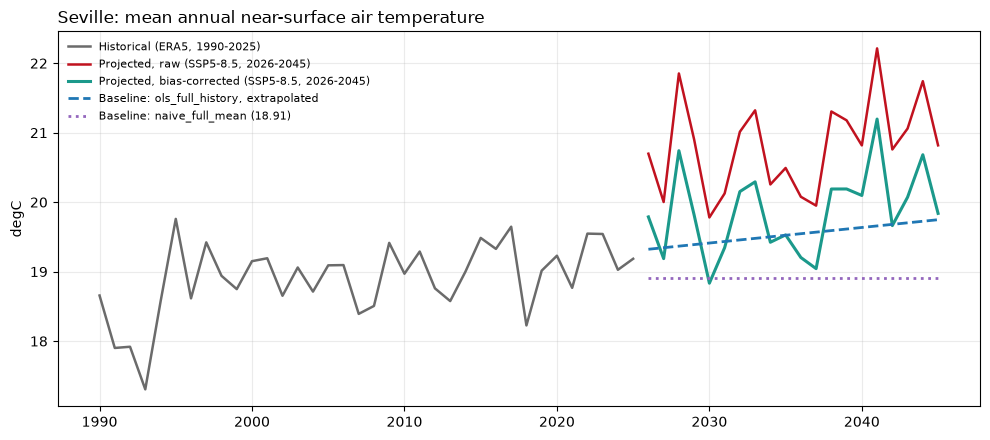

Historical mean: 18.91
Projected, bias-corrected: 19.86  (+0.96, +5.1%)
Projected, raw: 20.82  (+1.91, +10.1%)

Historical regression (1990-2025): +0.224/decade (p=0.01, significant).  Corrected projection's own trend (2026-2045): +0.341/decade (p=0.15, not significant).  Ratio: +1.52x


In [3]:
t2m = load("seville_t2m_mean_era5_vs_cmip6_raw_vs_corrected_v2")
s = change_stats(t2m)
b = fit_baselines(t2m, window=None)
plot_indicator(t2m, "degC", "Seville: mean annual near-surface air temperature", b, "ols_full_history")
print(f"Historical mean: {s['hist_mean']:.2f}")
print(f"Projected, bias-corrected: {s['corrected_mean']:.2f}  ({s['delta_corrected']:+.2f}, {s['pct_corrected']:+.1f}%)")
print(f"Projected, raw: {s['raw_mean']:.2f}  ({s['delta_raw']:+.2f}, {s['pct_raw']:+.1f}%)")
print()
print(trend_note(b))


**Result: +0.96 degC (+5.1%), historical to bias-corrected projection.** `t2m_mean` (the
whole-day average, not just the daytime maximum `tmax_mean` covers) rises from 18.91 degC (1990-2025)
to 19.86 degC (2026-2045) -- confirming the heat signal shows up in the overall daily mean, not only
in daytime highs. Raw shows the same too-warm pattern as `tmax_mean` (+1.91 degC, +10.1%, driven by
the same raw model bias). **Presentation note**: this and `tmax_mean` tell a consistent story from two
angles (mean vs. daytime max) -- worth showing together if there's time, or `t2m_mean` alone as the
single "how much does Seville warm overall" headline if only one temperature number is wanted.

**Trend comparison.** Unlike `tmax_mean`, `t2m_mean`'s historical trend (full 1990-2025 record) IS
statistically significant (+0.22 degC/decade, p=0.01) -- a confirmed historical warming rate, not just
a suggestive one. The bias-corrected projection's own trend (+0.34 degC/decade, p=0.15) is **about
1.5x steeper**, though not itself significant. **This is the strongest "possible acceleration" signal
of the five indicators**, precisely because it's the only one built on top of an already-confirmed
historical trend rather than two uncertain numbers being compared to each other.


## 3. Drying Conditions -- Total Annual Precipitation (`precip_total`)

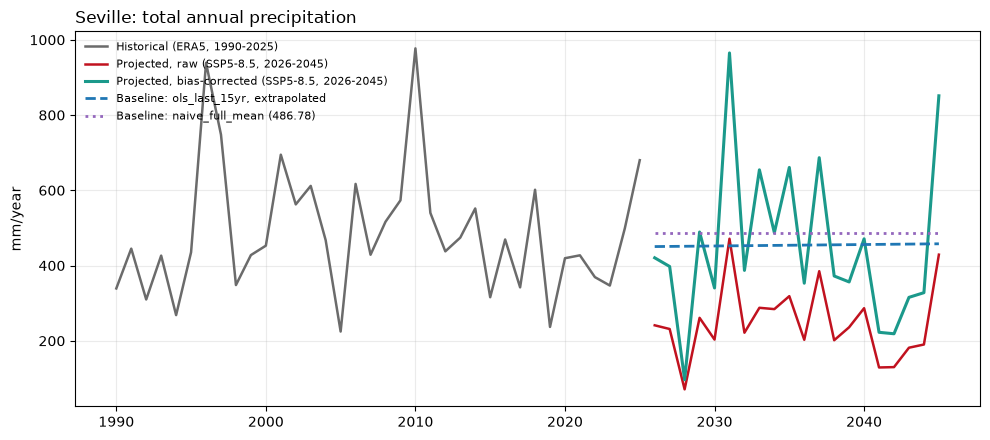

Historical mean: 486.78
Projected, bias-corrected: 453.71  (-33.07, -6.8%)
Projected, raw: 248.15  (-238.63, -49.0%)

Historical regression (2011-2025): +3.867/decade (p=0.96, not significant).  Corrected projection's own trend (2026-2045): -2.318/decade (p=0.98, not significant).  Ratio: -0.60x


In [4]:
precip = load("seville_precip_total_era5_vs_cmip6_raw_vs_corrected")
s = change_stats(precip)
b = fit_baselines(precip, window=15)
plot_indicator(precip, "mm/year", "Seville: total annual precipitation", b, "ols_last_15yr")
print(f"Historical mean: {s['hist_mean']:.2f}")
print(f"Projected, bias-corrected: {s['corrected_mean']:.2f}  ({s['delta_corrected']:+.2f}, {s['pct_corrected']:+.1f}%)")
print(f"Projected, raw: {s['raw_mean']:.2f}  ({s['delta_raw']:+.2f}, {s['pct_raw']:+.1f}%)")
print()
print(trend_note(b))


**Result: -33mm (-6.8%), historical to bias-corrected projection -- a real but modest drying
signal.** The raw model shows something far more dramatic (-49%, roughly half of Seville's historical
rainfall) -- **this raw number is not credible and should not be presented on its own**: raw CMIP6
output underestimates Seville's actual historical rainfall by nearly half even over the *reference*
period, a known, documented model bias, not a climate signal. The bias-corrected -6.8% is the honest
number: a real but modest drying trend, not the dramatic collapse the raw series would suggest.
**Presentation note**: if asked "does Seville get drier," the corrected answer is "yes, modestly" --
the interesting/severe part of the drying story is in the *extremes* (next panel), not the annual
total.

**Trend comparison.** Both the historical regression (+0.39mm/decade, `ols_last_15yr`) and the
corrected projection's own trend (-0.23mm/decade) are statistically indistinguishable from flat
(p=0.96 and p=0.98) -- **there is no real trend to compare here, historically or in the projection**.
The sign flip between them is noise, not a reversal worth mentioning in a presentation; the -6.8%
level shift reported above is the only meaningful number for this indicator.


## 4. Drought Severity -- Minimum 3-Month SPI (`min_spi3`)

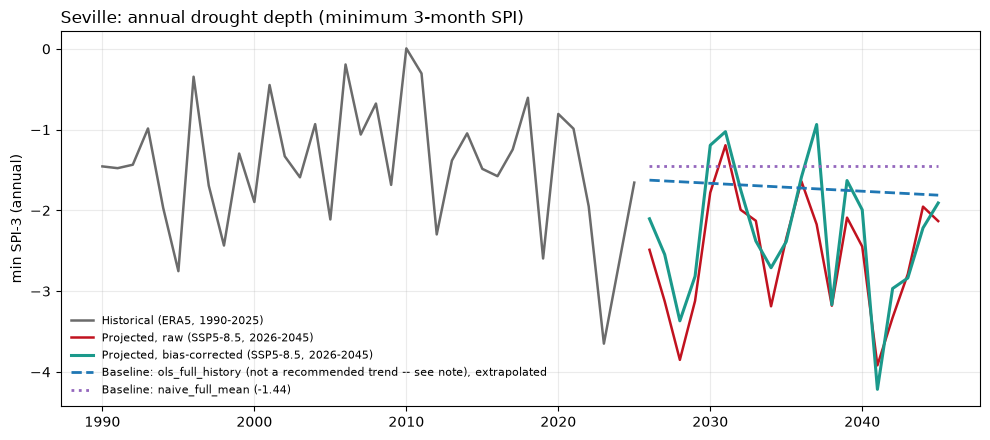

Historical mean: -1.44
Projected, bias-corrected: -2.29  (-0.84, +58.3%)
Projected, raw: -2.54  (-1.10, +76.1%)

Historical regression (1990-2025): -0.098/decade (p=0.45, not significant).  Corrected projection's own trend (2026-2045): -0.178/decade (p=0.59, not significant).  Ratio: +1.82x

SPI drought categories: -1.0 to -1.49 = moderate | -1.5 to -1.99 = severe | <= -2.0 = extreme


In [5]:
spi3 = load("seville_min_spi3_era5_vs_cmip6_raw_vs_corrected")
s = change_stats(spi3)
b = fit_baselines(spi3, window=None)
plot_indicator(spi3, "min SPI-3 (annual)", "Seville: annual drought depth (minimum 3-month SPI)", b, "ols_full_history (not a recommended trend -- see note)")
print(f"Historical mean: {s['hist_mean']:.2f}")
print(f"Projected, bias-corrected: {s['corrected_mean']:.2f}  ({s['delta_corrected']:+.2f}, {s['pct_corrected']:+.1f}%)")
print(f"Projected, raw: {s['raw_mean']:.2f}  ({s['delta_raw']:+.2f}, {s['pct_raw']:+.1f}%)")
print()
print(trend_note(b))
print()
print("SPI drought categories: -1.0 to -1.49 = moderate | -1.5 to -1.99 = severe | <= -2.0 = extreme")


**Result: drought depth deepens by -0.84, and crosses a meaningful severity line -- the standout
number of the four.** Historically, Seville's average worst 3-month window each year (-1.44) sits at
the edge of "moderate" drought. The bias-corrected projection (-2.29) sits solidly inside **"extreme"
drought** territory on the standard SPI scale (moderate: -1.0 to -1.49, severe: -1.5 to -1.99, extreme:
<= -2.0). **This is the single most presentation-worthy number in this notebook**: it's not just "more
negative," it's a full drought-category jump, on average, in the CMIP6 projection. One caveat worth
keeping in the back pocket, not necessarily on the slide: this indicator's own historical trend isn't
statistically significant (p=0.454, `Climate_Indicators_Modeling.ipynb`), so this is best framed as
"what SSP5-8.5 shows" rather than "confirming an already-established historical trend."

**Trend comparison.** Neither the historical regression (-0.10/decade, full record) nor the corrected
projection's own trend (-0.18/decade) is statistically significant (p=0.45 and p=0.59) -- consistent
with `Climate_Indicators_Modeling.ipynb`'s own finding that no regression reliably beats a flat
baseline for this indicator. The projection's slope is nominally about **1.8x steeper** (drought
deepening faster), but with neither trend confirmed, this should be read as "directionally consistent
with worsening drought," not as evidence of accelerating decline -- **the -0.84 level shift into
"extreme" territory, not the slope, is the number worth presenting.**


## 5. Fire Risk -- Days Above High Fire Danger (`days_fwi_gt30`)

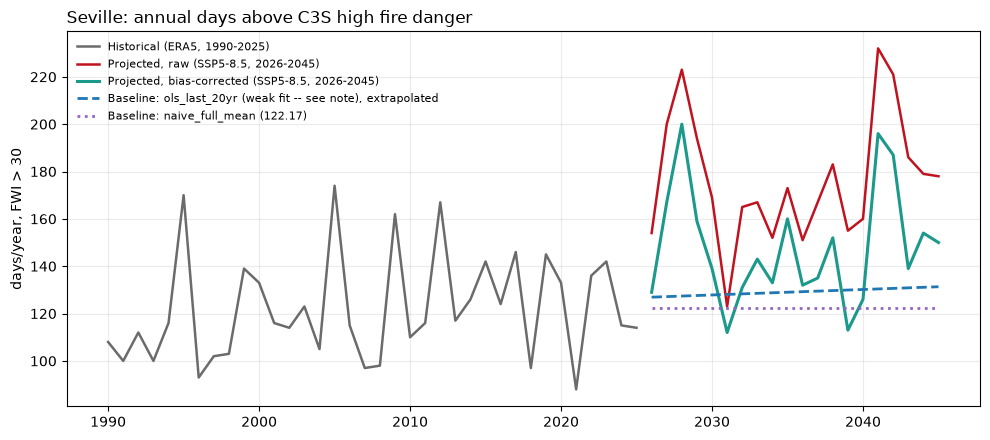

Historical mean: 122.17
Projected, bias-corrected: 147.85  (+25.68, +21.0%)
Projected, raw: 176.60  (+54.43, +44.6%)

Historical regression (2006-2025): +2.316/decade (p=0.79, not significant).  Corrected projection's own trend (2026-2045): +2.083/decade (p=0.84, not significant).  Ratio: +0.90x


In [6]:
fwi = load("seville_days_fwi_gt30_era5_vs_cmip6_raw_vs_corrected")
s = change_stats(fwi)
b = fit_baselines(fwi, window=20)
plot_indicator(fwi, "days/year, FWI > 30", "Seville: annual days above C3S high fire danger", b, "ols_last_20yr (weak fit -- see note)")
print(f"Historical mean: {s['hist_mean']:.2f}")
print(f"Projected, bias-corrected: {s['corrected_mean']:.2f}  ({s['delta_corrected']:+.2f}, {s['pct_corrected']:+.1f}%)")
print(f"Projected, raw: {s['raw_mean']:.2f}  ({s['delta_raw']:+.2f}, {s['pct_raw']:+.1f}%)")
print()
print(trend_note(b))


**Result: +26 days/year (+21%), historical to bias-corrected projection -- roughly a month more
of high fire danger per year.** Days above the C3S "high fire danger" threshold rise from 122 to 148
per year. Unusually for this notebook, **the raw series overstates the risk here rather than
understating it** (+45%, 177 days) -- the raw model's simultaneous heat and dry bias inflates raw fire
risk, and correction brings it back down, though the corrected increase is still real and substantial.
**Presentation note**: this is the only one of the four indicators where "raw vs. corrected" doesn't
follow the same direction as the other panels -- worth a one-line mention if the raw/corrected gap
comes up in Q&A, since it can look inconsistent otherwise (raw understates rainfall reduction but
overstates fire risk -- both are explained by the same underlying hot/dry raw bias, just interacting
differently with each indicator's formula).

**Trend comparison.** The historical regression (+2.3 days/decade) and the corrected projection's own
trend (+2.1 days/decade) are nearly identical -- neither significant (p=0.79 and p=0.84), and the
projection isn't accelerating beyond the historical rate the way the temperature indicators are
(ratio 0.90x, essentially flat continuation). **Unlike the other panels, the fire-risk story here is
almost entirely a level shift** (naive baseline 122 days vs. corrected projection 148 days), not a
trend story -- worth being precise about that distinction if asked "is the fire season trend
accelerating.


## Bottom line: the compound story holds together, even after correction

All five indicators point the same direction under SSP5-8.5 by mid-century (2026-2045), using the
bias-corrected series throughout:

| Indicator | Historical | Projected (corrected) | Change |
|---|---|---|---|
| `tmax_mean` (daytime heat) | 23.37 degC | 24.39 degC | **+1.03 degC (+4.4%)** |
| `t2m_mean` (overall warming) | 18.91 degC | 19.86 degC | **+0.96 degC (+5.1%)** |
| `precip_total` (drying) | 486.8 mm/yr | 453.7 mm/yr | **-33mm (-6.8%)** |
| `min_spi3` (drought) | -1.44 (moderate) | -2.29 (extreme) | **-0.84, a full drought-category jump** |
| `days_fwi_gt30` (fire risk) | 122.2 days/yr | 147.8 days/yr | **+25.7 days (+21.0%)** |

Hotter days and hotter overall averages, modestly less annual rain, but a much deeper drought signal
in the worst 3-month stretch each year, and roughly a month more of high fire-danger days annually --
a coherent, mutually-reinforcing heat -> drought -> fire risk pathway, not five independent findings.
The directional consistency survives bias correction, which matters: this isn't an artifact of the
raw model's known biases, since correcting those biases (which pulls in different directions for
different indicators, as noted above) still leaves every indicator pointing the same way.

**Standard caveat, one last time**: one model, one scenario, no ensemble spread -- present this as
"the directional risk SSP5-8.5 shows for Seville," not as a calibrated, confirmed forecast.

### Trend comparison, across all five

| Indicator | Historical trend | Projection's own trend | Ratio | Read |
|---|---|---|---|---|
| `tmax_mean` | +0.20/decade (n.s.) | +0.35/decade (n.s.) | 1.8x | possible acceleration, unconfirmed |
| `t2m_mean` | +0.22/decade (**sig., p=0.01**) | +0.34/decade (n.s.) | 1.5x | **strongest acceleration signal** -- built on a confirmed base rate |
| `precip_total` | +0.39mm/decade (n.s.) | -0.23mm/decade (n.s.) | -- | no real trend either way -- noise |
| `min_spi3` | -0.10/decade (n.s.) | -0.18/decade (n.s.) | 1.8x | directionally worse, not confirmed -- the level shift is the real story |
| `days_fwi_gt30` | +2.3 days/decade (n.s.) | +2.1 days/decade (n.s.) | 0.9x | flat continuation -- also a level-shift story, not a trend story |

**For the presentation**: only `t2m_mean` supports an "acceleration" claim with any statistical
footing, since it's the only indicator where the historical trend itself is confirmed. For the other
four, the honest framing is "the projection is consistent with continuing or modestly steepening
historical patterns," not "the trend is accelerating" -- and for `precip_total` and `days_fwi_gt30`
specifically, the risk story is really about the *level* (how high/low the projected average sits),
not the *slope*.


---

# Larissa Results Summary: Chronic Warming vs. a Precipitation Reversal

Presentation-ready summary of Larissa's four key climate-risk indicators, historical (ERA5, 1990-2025)
vs. projected (CMIP6 SSP5-8.5, `cmcc_esm2`, 2026-2045) -- same format as the Seville section above.

**Source data**: `larissa_cmip6_projection_eda.ipynb` (Section 16) and
`Calculating_SPI_for_Larissa_Projection.ipynb` -- nothing recomputed here, this notebook only reads
and presents.

**This story looks different from Seville's, and that difference is the headline.** Larissa's
chronic-warming indicator (`tmin_mean`) continues its historical trend cleanly. But all three
precipitation-linked indicators (`precip_total`, `max_week_precip_mm`, `min_spi3`) run in the
*opposite* direction from Larissa's historical record -- history shows significant wetting and
flat-to-improving drought; the projection shows drying and deepening drought. **Present this as an
open tension, not a resolved finding** -- one climate model's projection disagreeing with a
well-documented historical trend, across three independent indicators, is worth flagging clearly
rather than picking whichever side is more convenient.

**Same caveat as the Seville section**: single model (`cmcc_esm2`), single scenario (SSP5-8.5), no
ensemble spread.


## 1. Chronic Warming -- Mean Daily Minimum Temperature (`tmin_mean`)

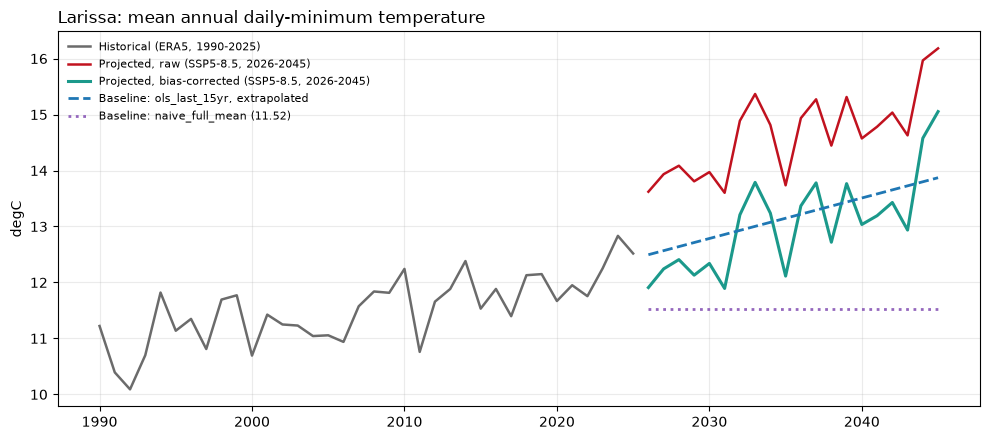

Historical mean: 11.52
Projected, bias-corrected: 13.06  (+1.53, +13.3%)
Projected, raw: 14.65  (+3.13, +27.1%)

Historical regression (2011-2025): +0.724/decade (p=0.01, significant).  Corrected projection's own trend (2026-2045): +1.093/decade (p=0.00, significant).  Ratio: +1.51x


In [7]:
tmin = load("larissa_tmin_mean_era5_vs_cmip6_raw_vs_corrected", OUT_LARISSA)
s = change_stats(tmin)
b = fit_baselines(tmin, window=15)
plot_indicator(tmin, "degC", "Larissa: mean annual daily-minimum temperature", b, "ols_last_15yr")
print(f"Historical mean: {s['hist_mean']:.2f}")
print(f"Projected, bias-corrected: {s['corrected_mean']:.2f}  ({s['delta_corrected']:+.2f}, {s['pct_corrected']:+.1f}%)")
print(f"Projected, raw: {s['raw_mean']:.2f}  ({s['delta_raw']:+.2f}, {s['pct_raw']:+.1f}%)")
print()
print(trend_note(b))


**Result: +1.53 degC (+13.3%), historical to bias-corrected projection -- and it lands almost
exactly on the historical trend line.** `tmin_mean` rises from 11.52 degC (1990-2025) to 13.06 degC
(2026-2045). Unlike every other Larissa indicator below, this one's historical regression is itself
highly significant (p=0.010 even on just the last-15-year window; p<0.0001 on the full record per
`Climate_Indicators_Modeling_Larissa.ipynb`), and the projection's own trend (p<0.001) confirms it
cleanly rather than diverging. **Presentation note**: this is the safest, most defensible number in
Larissa's story -- nighttime warming continuing an already-confirmed trend, no caveats needed beyond
the standard one-model-one-scenario note.


## 2. Precipitation -- Total Annual Precipitation (`precip_total`)

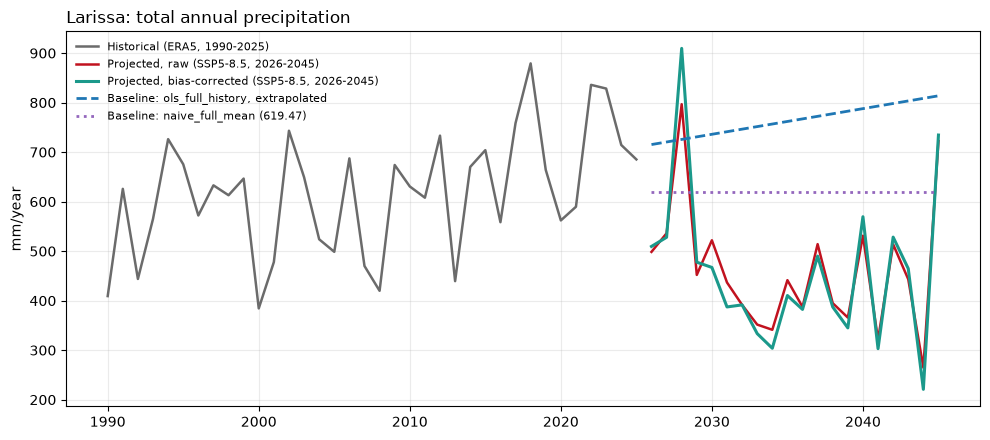

Historical mean: 619.5 mm/yr
Projected, bias-corrected: 457.2 mm/yr  (-162.3, -26.2%)
Projected, raw: 461.3 mm/yr  (-158.1, -25.5%)

Historical regression (1990-2025): +51.814/decade (p=0.01, significant).  Corrected projection's own trend (2026-2045): -50.010/decade (p=0.42, not significant).  Ratio: -0.97x


In [8]:
precip = load("larissa_precip_total_era5_vs_cmip6_raw_vs_corrected", OUT_LARISSA)
s = change_stats(precip)
b = fit_baselines(precip, window=None)
plot_indicator(precip, "mm/year", "Larissa: total annual precipitation", b, "ols_full_history")
print(f"Historical mean: {s['hist_mean']:.1f} mm/yr")
print(f"Projected, bias-corrected: {s['corrected_mean']:.1f} mm/yr  ({s['delta_corrected']:+.1f}, {s['pct_corrected']:+.1f}%)")
print(f"Projected, raw: {s['raw_mean']:.1f} mm/yr  ({s['delta_raw']:+.1f}, {s['pct_raw']:+.1f}%)")
print()
print(trend_note(b))


**Result: -162mm (-26.2%), historical to bias-corrected projection -- and this reverses a
statistically significant historical trend, not just an insignificant one.** Larissa's historical
`precip_total` trend is genuinely significant (+51.8mm/decade, p=0.007, the strongest precipitation
trend either city has produced) -- yet the projection averages 457mm/yr, well below even the flat
historical mean (619mm/yr), let alone where that trend was heading. **Not a correction artifact**: raw
(461mm) and corrected (457mm) are nearly identical, so this is what the model itself simulates, not a
bias-correction effect. **Presentation note**: this is the number that most directly contradicts
Larissa's "intensifying wet extremes" framing -- worth stating plainly rather than glossing over, and
worth pairing with the caveat that one model reversing a 36-year significant trend is exactly the kind
of result that needs a second model to confirm before it's trusted on its own.


## 3. Flood Peak Intensity -- Maximum Single-Week Precipitation (`max_week_precip_mm`)

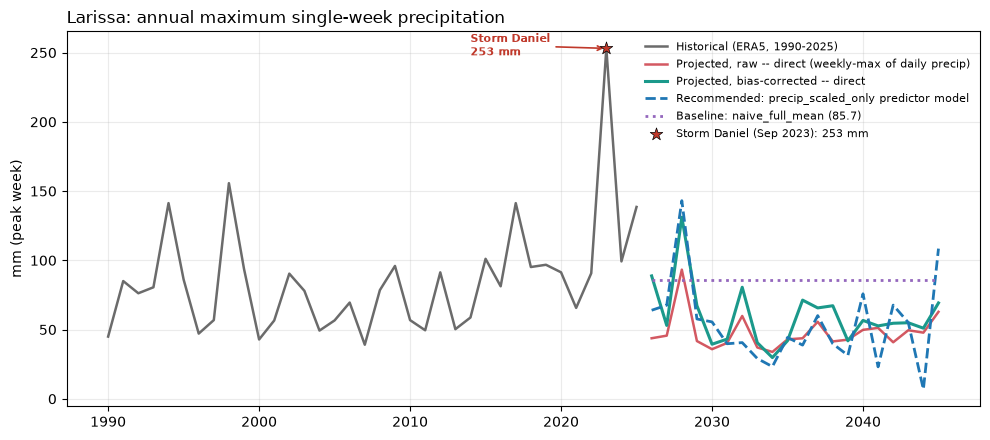

Historical mean: 85.7 mm
Projected, bias-corrected (direct): 60.0 mm  (-25.7, -30.0%)
Projected, raw (direct): 48.0 mm  (-37.7, -44.0%)
Projected, recommended predictor model: 53.6 mm  (-32.1, -37.5%)
Storm Daniel (Sep 2023): 253 mm -- 3.0x the historical average, 4.2x the bias-corrected projected average


In [9]:
mw = load("larissa_max_week_precip_mm_era5_vs_cmip6_raw_vs_corrected", OUT_LARISSA)
mw_hist = mw["era5_historical"].dropna()
mw_raw = mw["cmip6_raw_direct"].dropna()
mw_corr = mw["cmip6_biascorrected_direct"].dropna()
mw_pred = mw["baseline_precip_scaled_only"].dropna()
mw_naive = mw["baseline_naive_full_mean"].dropna().iloc[0]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(mw.index, mw["era5_historical"], color=COLOR_HIST, lw=1.8, label="Historical (ERA5, 1990-2025)")
ax.plot(mw.index, mw["cmip6_raw_direct"], color=COLOR_RAW, lw=1.8, alpha=0.7,
        label="Projected, raw -- direct (weekly-max of daily precip)")
ax.plot(mw.index, mw["cmip6_biascorrected_direct"], color=COLOR_CORRECTED, lw=2.2,
        label="Projected, bias-corrected -- direct")
ax.plot(mw_pred.index, mw_pred.values, "--", color=COLOR_REGRESSION, lw=2,
        label="Recommended: precip_scaled_only predictor model")
ax.plot(mw_pred.index, [mw_naive] * len(mw_pred), ":", color=COLOR_NAIVE, lw=2,
        label=f"Baseline: naive_full_mean ({mw_naive:.1f})")

# Storm Daniel, Sep 2023 -- the real event that anchors Larissa's historical flood-risk profile.
# Already present in the historical series (the 2023 point); marked explicitly here rather than
# left as an unlabeled peak, since it's the single most presentation-relevant data point on this plot.
storm_daniel_year, storm_daniel_mm = 2023, mw.loc[2023, "era5_historical"]
ax.scatter([storm_daniel_year], [storm_daniel_mm], color="#c0392b", s=90, zorder=5, marker="*",
           edgecolor="black", linewidth=0.5,
           label=f"Storm Daniel (Sep 2023): {storm_daniel_mm:.0f} mm")
ax.annotate(f"Storm Daniel\n{storm_daniel_mm:.0f} mm", xy=(storm_daniel_year, storm_daniel_mm),
            xytext=(storm_daniel_year - 9, storm_daniel_mm - 5), fontsize=8, color="#c0392b",
            fontweight="bold", ha="left",
            arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.2))
ax.set_ylabel("mm (peak week)")
ax.set_title("Larissa: annual maximum single-week precipitation", fontsize=12, loc="left")
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Historical mean: {mw_hist.mean():.1f} mm")
print(f"Projected, bias-corrected (direct): {mw_corr.mean():.1f} mm  "
      f"({mw_corr.mean()-mw_hist.mean():+.1f}, {100*(mw_corr.mean()-mw_hist.mean())/mw_hist.mean():+.1f}%)")
print(f"Projected, raw (direct): {mw_raw.mean():.1f} mm  "
      f"({mw_raw.mean()-mw_hist.mean():+.1f}, {100*(mw_raw.mean()-mw_hist.mean())/mw_hist.mean():+.1f}%)")
print(f"Projected, recommended predictor model: {mw_pred.mean():.1f} mm  "
      f"({mw_pred.mean()-mw_hist.mean():+.1f}, {100*(mw_pred.mean()-mw_hist.mean())/mw_hist.mean():+.1f}%)")
print(f"Storm Daniel (Sep 2023): {storm_daniel_mm:.0f} mm -- "
      f"{storm_daniel_mm/mw_hist.mean():.1f}x the historical average, "
      f"{storm_daniel_mm/mw_corr.mean():.1f}x the bias-corrected projected average")


**Result: -30% (direct) to -37.5% (recommended model), historical to projected -- no version of
this indicator shows intensification.** This indicator is structurally different from the others: its
best model isn't a year trend but a regression on `precip_total` itself (`max_week_precip_mm ~
precip_scaled`, the only model that robustly beat naive historically). Feeding the projection's
depressed `precip_total` through that model gives 53.6mm -- below even the direct weekly-max
computed straight from the projected daily series (60.0mm). Both are well below the historical average
(85.7mm). **Presentation note**: Larissa's historical `max_week_precip_mm` trend was itself
borderline-significant and *increasing* (Kendall p=0.0206) -- directly motivated by events like Storm
Daniel (Sep 2023). This projection shows the opposite. Combined with `precip_total` above, this is now
two independent precipitation indicators pointing away from Larissa's historical flood-intensification
story under this one model/scenario.


## 4. Drought Severity -- Minimum 3-Month SPI (`min_spi3`)

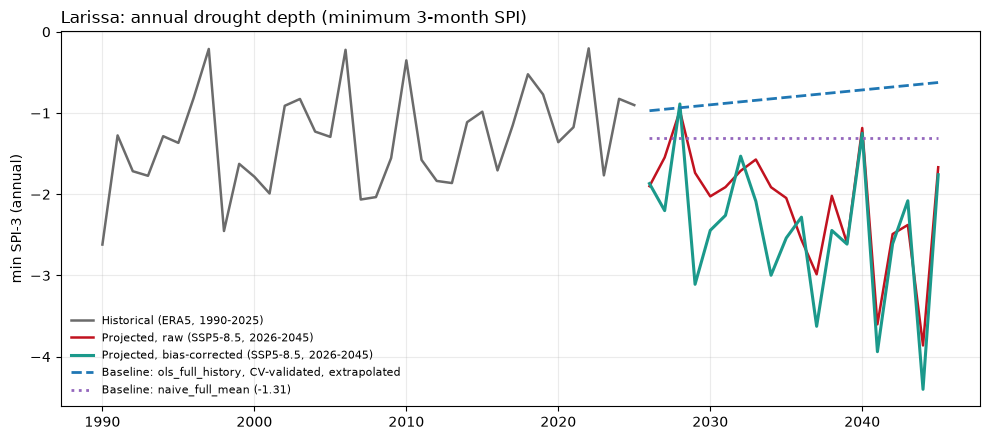

Historical mean: -1.31
Projected, bias-corrected: -2.45  (-1.14)
Projected, raw: -2.13  (-0.82)

SPI drought categories: -1.0 to -1.49 = moderate | -1.5 to -1.99 = severe | <= -2.0 = extreme

Historical regression (1990-2025): +0.183/decade (p=0.06, not significant).  Corrected projection's own trend (2026-2045): -0.489/decade (p=0.15, not significant).  Ratio: -2.68x


In [10]:
spi3 = load("larissa_min_spi3_era5_vs_cmip6_raw_vs_corrected", OUT_LARISSA)
s = change_stats(spi3)
b = fit_baselines(spi3, window=None)
plot_indicator(spi3, "min SPI-3 (annual)", "Larissa: annual drought depth (minimum 3-month SPI)", b, "ols_full_history, CV-validated")
print(f"Historical mean: {s['hist_mean']:.2f}")
print(f"Projected, bias-corrected: {s['corrected_mean']:.2f}  ({s['delta_corrected']:+.2f})")
print(f"Projected, raw: {s['raw_mean']:.2f}  ({s['delta_raw']:+.2f})")
print()
print("SPI drought categories: -1.0 to -1.49 = moderate | -1.5 to -1.99 = severe | <= -2.0 = extreme")
print()
print(trend_note(b))


**Result: a full drought-category jump, and a reversed trend direction -- the third precipitation
indicator to disagree with history.** Historical `min_spi3` averages -1.31 (moderate drought) with a
*marginally improving* trend (+0.18/decade, p=0.061). The bias-corrected projection averages **-2.45
-- extreme drought territory** -- and its own trend runs the opposite way, worsening at -0.49/decade
(p=0.15). Raw (-2.13) agrees this is severe, so it isn't a correction artifact. **Note on the baseline shown**: `min_spi3` was originally excluded from
`Climate_Indicators_Modeling_Larissa.ipynb`'s CV-based model search by design (flat/uncorrelated with
the flood side), but that notebook's Section 14 has since run the check specifically for this
indicator anyway -- `ols_full_history` (the model shown here) beats naive robustly (+11.4% CV-average
improvement, +26% single-split). This is a validated baseline, not a placeholder, which strengthens
this finding rather than weakening it. **Presentation note**: with `precip_total` and
`max_week_precip_mm`, this makes three independently-built indicators all reversing Larissa's
historical precipitation story in the same direction, now against a properly validated baseline for
all three -- state this as a genuine, coherent tension worth further checking (a second model/scenario),
not as confirmed worsening drought risk.


## 5. Extreme Precipitation -- Annual Maximum 1-Day Rainfall (`rx1day_mm`)

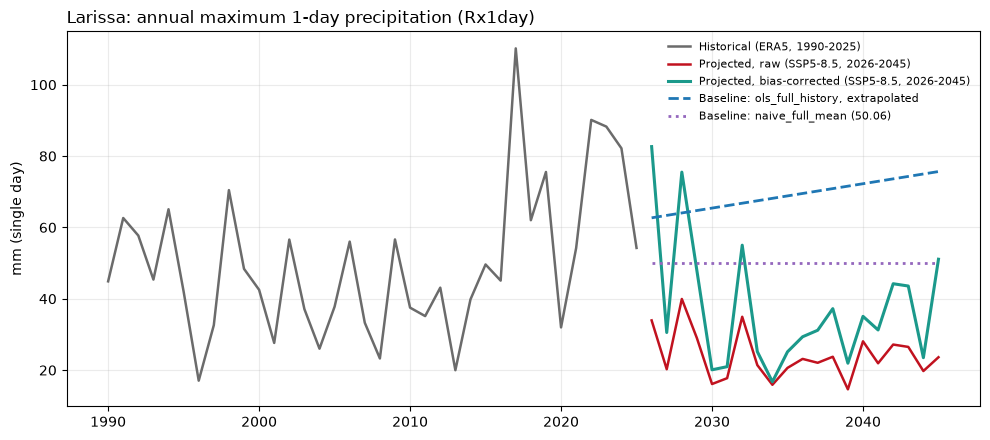

Historical mean: 50.1 mm
Projected, bias-corrected: 37.4 mm  (-12.7, -25.3%)
Projected, raw: 24.0 mm  (-26.0, -52.0%)

Historical regression (1990-2025): +6.828/decade (p=0.04, significant).  Corrected projection's own trend (2026-2045): -8.415/decade (p=0.24, not significant).  Ratio: -1.23x


In [11]:
rx1day = load("larissa_rx1day_mm_era5_vs_cmip6_raw_vs_corrected", OUT_LARISSA)
s = change_stats(rx1day)
b = fit_baselines(rx1day, window=None)
plot_indicator(rx1day, "mm (single day)", "Larissa: annual maximum 1-day precipitation (Rx1day)", b, "ols_full_history")
print(f"Historical mean: {s['hist_mean']:.1f} mm")
print(f"Projected, bias-corrected: {s['corrected_mean']:.1f} mm  ({s['delta_corrected']:+.1f}, {s['pct_corrected']:+.1f}%)")
print(f"Projected, raw: {s['raw_mean']:.1f} mm  ({s['delta_raw']:+.1f}, {s['pct_raw']:+.1f}%)")
print()
print(trend_note(b))

**Result: -25.3% (bias-corrected), historical to projection -- and this reverses the only
*statistically significant* historical trend among Larissa's precipitation-extreme indicators.**
Historical `rx1day_mm` averages 50.1mm with a genuinely significant increasing trend (+6.8mm/decade,
p=0.04) -- yet the bias-corrected projection falls to 37.4mm, and its own within-period trend runs
the opposite way (-8.4mm/decade, though not itself significant, p=0.24). Raw shows an even steeper
apparent decline (-52.0%, 24.0mm), but the corrected series should be trusted here as elsewhere.
**Presentation note**: this is now the *fourth* independently-built precipitation indicator (with
`precip_total`, `max_week_precip_mm`, `min_spi3`) to reverse Larissa's historical wetting story under
SSP5-8.5 -- and the only one where the historical trend it reverses is itself confirmed significant,
making this arguably the single most presentation-worthy precipitation-reversal number in the
notebook, precisely because there's no ambiguity about what history actually showed.

## 6. Precipitation Intensity -- Simple Daily Intensity Index (`sdii_mm`)

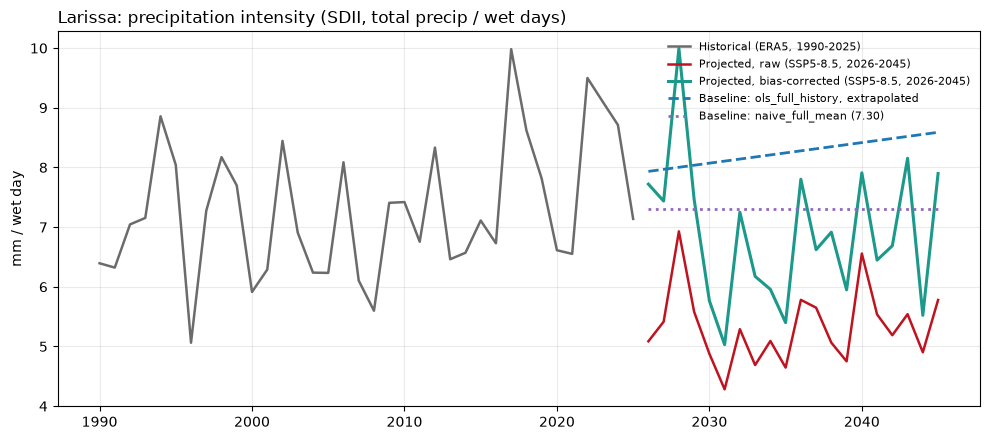

Historical mean: 7.30 mm/wet day
Projected, bias-corrected: 6.91 mm/wet day  (-0.39, -5.4%)
Projected, raw: 5.33 mm/wet day  (-1.96, -26.9%)

Historical regression (1990-2025): +0.345/decade (p=0.06, not significant).  Corrected projection's own trend (2026-2045): -0.259/decade (p=0.59, not significant).  Ratio: -0.75x


In [12]:
sdii = load("larissa_sdii_mm_era5_vs_cmip6_raw_vs_corrected", OUT_LARISSA)
s = change_stats(sdii)
b = fit_baselines(sdii, window=None)
plot_indicator(sdii, "mm / wet day", "Larissa: precipitation intensity (SDII, total precip / wet days)", b, "ols_full_history")
print(f"Historical mean: {s['hist_mean']:.2f} mm/wet day")
print(f"Projected, bias-corrected: {s['corrected_mean']:.2f} mm/wet day  ({s['delta_corrected']:+.2f}, {s['pct_corrected']:+.1f}%)")
print(f"Projected, raw: {s['raw_mean']:.2f} mm/wet day  ({s['delta_raw']:+.2f}, {s['pct_raw']:+.1f}%)")
print()
print(trend_note(b))

**Result: -5.4% (bias-corrected), historical to projection -- a modest decline, the smallest of
Larissa's five precipitation-linked indicators.** SDII (rainfall intensity per wet day) falls from
7.30 to 6.91 mm/wet day. The historical trend is only borderline (+0.35/decade, p=0.06, not quite
significant), and the projection's own trend (-0.26/decade, p=0.59) isn't either. **Presentation
note**: unlike `rx1day_mm` (the single worst day) or `precip_total` (the annual sum), SDII asks a
narrower question -- when it does rain, how hard, on average -- and the answer here is "barely
different," not a reversal worth emphasizing on its own. Read this alongside `rx1day_mm`: the worst
single day gets notably less extreme (-25.3%), while typical rainy-day intensity barely moves
(-5.4%) -- together they suggest the historical wetting trend was concentrated in extreme events more
than everyday rain, and it's specifically those extremes the projection walks back.

## Bottom line: chronic warming continues history; the precipitation story reverses it

| Indicator | Historical | Projected (corrected) | Change |
|---|---|---|---|
| `tmin_mean` (chronic warming) | 11.52 degC | 13.06 degC | **+1.53 degC (+13.3%), on-trend** |
| `precip_total` (precipitation) | 619.5 mm/yr | 457.2 mm/yr | **-162mm (-26.2%), reverses a significant historical trend** |
| `max_week_precip_mm` (flood peak) | 85.7 mm | 53.6-60.0 mm | **-30% to -37.5%, reverses history** |
| `min_spi3` (drought) | -1.31 (moderate) | -2.45 (extreme) | **-1.14, a full drought-category jump, trend reversed** |
| `rx1day_mm` (worst single day) | 50.1 mm | 37.4 mm | **-25.3%, reverses a *significant* historical trend** |
| `sdii_mm` (typical rain-day intensity) | 7.30 mm/wet day | 6.91 mm/wet day | **-5.4%, modest, not the driver of the other reversals** |

Larissa's chronic nighttime warming is the cleanest, most defensible number in this notebook --
a confirmed historical trend, continuing smoothly into the projection. The other five indicators tell
a different story: all five are built from precipitation, and all five run *against* Larissa's
historical record under this one model/scenario -- less annual rain, a less extreme wettest week and
worst single day, milder typical rain-day intensity, and deeper drought, where history showed the
opposite (significant wetting, flat-to-improving drought). Notably, `rx1day_mm` reverses a trend that
was itself independently *significant* historically (p=0.04), not just a suggestive one -- arguably
the cleanest single piece of evidence for the reversal, since there's no ambiguity about what the
historical record showed. Comparing `rx1day_mm` against `sdii_mm` also sharpens the story: the worst
single day of the year gets notably less extreme (-25.3%), while typical rainy-day intensity barely
moves (-5.4%) -- the historical wetting trend, and its projected reversal, looks concentrated in
extreme events rather than everyday rainfall.

**For the presentation**: don't present these six as a single unified narrative the way Seville's
five indicators can be. The honest framing is two separate stories -- **(1) chronic warming, confirmed
and continuing**, and **(2) a precipitation-side reversal that contradicts 36 years of observed
trends, worth flagging as an open question rather than a finding**, since it rests on a single climate
model's simulation disagreeing with statistically significant historical data.

**Standard caveat, one last time**: one model, one scenario, no ensemble spread -- and for the
precipitation reversal specifically, a second model or scenario would be the natural next check before
this changes how Larissa's flood/drought risk gets presented.


---

# Seville vs. Larissa: Two Climate Stories Under SSP5-8.5

Direct comparison of both cities' projections, with the local geography that explains why their
historical climate signatures -- and their projected trajectories -- diverge the way they do.
Geographic and historical-event details below are pulled from
`documentation/Seville_Larissa_Key_Findings_vs_Hypotheses.md`, not re-derived here.

## Why these two cities aren't climatologically similar to begin with

| | Seville | Larissa |
|---|---|---|
| Location | 37.25-37.50N, 6.00-5.75W -- southern Spain, the Guadalquivir valley | 39.50-39.75N, 22.25-22.50E -- central Greece, the Thessalian plain |
| Setting | ~80 km from the Atlantic; mild, ocean-moderated winter | Inland plain ringed by mountains (Pindus to the west); no ocean moderation |
| January mean (ERA5, historical) | 10.6 degC | 5.1 degC -- genuinely continental |
| July mean (ERA5, historical) | 27.7 degC | 26.9 degC -- similar peak heat despite the winter gap |
| Annual temperature amplitude | 17.1 degC | 21.7 degC -- wider swings, continental climate |
| Distance apart | ~2,300 km -- no shared weather systems | |

Two real, documented events anchor each city's historical risk profile and motivated this project's
original hypotheses: **Seville's July 2022 heatwave** (peak 39.8 degC) and **April 2023 drought**
(SPI-3 = -3.65, the most severe reading in the 36-year record) -- the same 2022-2023 Andalusia
drought widely reported in the press. **Larissa's September 2023 Storm Daniel flood** (253mm in a
single week, the record year by a wide margin over the next-highest 155.7mm) and its **July 2023
heatwave**, notable because nighttime temperatures never dropped below the 20 degC tropical-night
threshold for 9 straight days -- day *and* night stayed elevated together, which is why `tmin_mean`
(not `tmax_mean`) is Larissa's headline heat indicator. Greece/the Eastern Mediterranean is
independently documented in the wider climate literature as one of the faster-warming Mediterranean
subregions, consistent with Larissa's historical signature being, if anything, more complete than
Seville's (both day and night warming, not just daytime).

## The projected stories, side by side

| | Seville (heat -> drought -> fire) | Larissa (chronic warming, precip split) |
|---|---|---|
| Temperature | `tmax_mean` +1.03 degC (+4.4%) -- continues history | `tmin_mean` +1.53 degC (+13.3%) -- continues history, on-trend |
| Precipitation | `precip_total` -33mm (-6.8%) -- modest, continues a (non-significant) historical pattern | `precip_total` -162mm (-26.2%) -- **reverses** a *significant* historical wetting trend |
| Extreme precip | (not separately tracked for Seville) | `max_week_precip_mm` -30% to -37.5% -- **reverses** history |
| Drought | `min_spi3` -0.84, moderate -> extreme category jump | `min_spi3` -1.14, moderate -> extreme category jump, trend also reverses |
| Fire/flood risk | `days_fwi_gt30` +25.7 days (+21.0%) -- continues history | -- (no Larissa fire panel; flood risk is the closer analogue, and it points the opposite way from history) |

## The core comparative finding

**Seville's projection is directionally boring, in the best sense -- it continues the story its
historical record already tells.** Hotter, drier, deeper drought, more fire-danger days: every
indicator points the same way history already pointed, just further along. That's the expected,
unsurprising result for a city whose July 2022/April 2023 events already demonstrated exactly this
compound vulnerability.

**Larissa's projection splits its own historical story in two.** The chronic-warming indicator
(`tmin_mean`) behaves exactly like Seville's -- a clean continuation of an already-significant trend.
But every precipitation-linked indicator reverses direction: less annual rain, a less extreme wettest
week, deeper drought -- directly contradicting a *statistically significant* historical wetting trend,
and sitting in tension with the community's very recent lived experience of Storm Daniel.

## A caveat specific to this divergence, worth having ready

**A lower projected *average* extreme-week precipitation does not mean events like Storm Daniel become
impossible, or even necessarily less likely.** `cmcc_esm2`'s native grid resolution is coarse --
roughly 0.94 degrees latitude by 1.25 degrees longitude, on the order of 100km, against ERA5's 0.25
degrees (`documentation/projection_data_pull_plan.md`). Intense, localized convective/frontal
rainfall events -- exactly the kind that produced Storm Daniel -- are notoriously difficult for
coarse-grid climate models to resolve; a model can show a drier *average* future while still missing
whether short, extreme events intensify. Read the `max_week_precip_mm` reversal as "this model's
central tendency moved the opposite way from history," not as "catastrophic flood risk is
decreasing" -- those are different claims, and only the first one is what this analysis actually
supports.

## For the presentation

- **Lead with Seville** if the goal is a clean, confirmatory climate-risk story -- every indicator
  agrees with itself, historically and going forward.
- **Use Larissa to show nuance and honesty**, not just a second confirmatory case -- a real signal
  (chronic warming) sitting alongside a real, unresolved tension (precipitation reversal) is a more
  credible presentation than forcing both cities into the same "everything gets worse" narrative,
  and it's the more scientifically honest read of what this single-model/single-scenario analysis
  actually shows.
- **Both stories share the same limitation**: one model (`cmcc_esm2`), one scenario (SSP5-8.5), no
  ensemble spread. Seville's directional consistency makes that caveat feel less urgent; Larissa's
  reversal makes it essential to state explicitly.
